In [29]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

In [30]:
df_train = pd.read_csv('train_landmark_features.csv')
df_test = pd.read_csv('test_landmark_features.csv')

In [31]:
# Menampilkan data yang memiliki missing values di df_train
missing_train = df_train[df_train.isnull().any(axis=1)]
print(missing_train)

# Menampilkan data yang memiliki missing values di df_test
missing_test = df_test[df_test.isnull().any(axis=1)]
print(missing_test)


            D1        D2        D3        D4        D5        D6        D7  \
1138  0.194242  0.142394  0.150192  0.141353  0.128944  0.105793  0.076602   
1381  0.202018  0.145410  0.151532  0.140136  0.126476  0.101626  0.073153   
1905  0.195748  0.131172  0.147092  0.140452  0.130499  0.110592  0.079634   

            D8        D9       D10  ...     angle1     angle2     angle3  \
1138  0.040164  0.020316  0.041190  ...  68.412492  54.108068  75.145714   
1381  0.039663  0.019985  0.039930  ...  66.331347  50.946379  73.457574   
1905  0.043131  0.021679  0.041184  ...  75.191648  58.604398  77.724774   

          angle4      angle5  angle6      angle7      rahang       atas  \
1138  155.092555  169.166703     NaN  162.597296  103.129138  73.466273   
1381  148.013051  173.352704     NaN  165.804010  104.911440  76.305180   
1905  161.387206  160.343017     NaN  168.280401  108.733326  84.376366   

       label  
1138    Oval  
1381    Oval  
1905  Square  

[3 rows x 34 columns

In [32]:
# Menghapus baris dengan nilai NaN dari df_train
df_train_cleaned = df_train.dropna()

# Menghapus baris dengan nilai NaN dari df_test
df_test_cleaned = df_test.dropna()

# Menampilkan hasil setelah penghapusan
print("Dataset train setelah penghapusan missing values:")
print(df_train_cleaned)

print("Dataset test setelah penghapusan missing values:")
print(df_test_cleaned)


Dataset train setelah penghapusan missing values:
            D1        D2        D3        D4        D5        D6        D7  \
0     0.196476  0.141174  0.152380  0.144882  0.129728  0.104423  0.072919   
1     0.205371  0.130877  0.152245  0.144959  0.128864  0.102936  0.074437   
2     0.198534  0.140274  0.151720  0.144329  0.129644  0.105062  0.073267   
3     0.208583  0.135839  0.150546  0.141539  0.127406  0.104252  0.073385   
4     0.195294  0.143022  0.151350  0.143047  0.128826  0.105184  0.074456   
...        ...       ...       ...       ...       ...       ...       ...   
2341  0.185082  0.142002  0.152015  0.145666  0.133001  0.108936  0.076007   
2342  0.185125  0.142344  0.150787  0.143896  0.132357  0.109332  0.077117   
2343  0.180025  0.142519  0.154429  0.147129  0.132543  0.109441  0.075398   
2344  0.187882  0.135997  0.154840  0.148496  0.133252  0.109142  0.074882   
2345  0.191285  0.134543  0.152841  0.145339  0.134126  0.109232  0.074492   

            D

In [33]:
df_train.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,angle1,angle2,angle3,angle4,angle5,angle6,angle7,rahang,atas,label
0,0.196476,0.141174,0.152380,0.144882,0.129728,0.104423,0.072919,0.038322,0.019696,0.040726,...,63.528264,51.486861,74.184182,155.223116,170.297623,169.788924,153.225075,101.244496,68.388956,Heart
1,0.205371,0.130877,0.152245,0.144959,0.128864,0.102936,0.074437,0.039810,0.020500,0.042205,...,61.865429,49.373542,74.463166,152.940964,172.594637,168.142027,152.318938,106.974563,71.182830,Heart
2,0.198534,0.140274,0.151720,0.144329,0.129644,0.105062,0.073267,0.037886,0.019285,0.040156,...,65.816770,53.696661,74.243606,154.891796,169.461020,169.187581,158.369113,101.825530,78.234916,Heart
3,0.208583,0.135839,0.150546,0.141539,0.127406,0.104252,0.073385,0.038621,0.019828,0.040330,...,65.477757,51.769746,74.051078,157.968766,167.735226,172.832452,153.758650,98.382084,76.822178,Heart
4,0.195294,0.143022,0.151350,0.143047,0.128826,0.105184,0.074456,0.039001,0.019820,0.040279,...,67.534936,54.035338,74.112601,156.542287,167.203922,170.730699,159.372365,105.068951,77.943796,Heart


In [34]:
X_train = df_train_cleaned.iloc[:,:-1]
X_test = df_test_cleaned.iloc[:,:-1]
y_train = df_train_cleaned.iloc[:,-1]
y_test = df_test_cleaned.iloc[:,-1]

In [35]:
X_train.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,R10,angle1,angle2,angle3,angle4,angle5,angle6,angle7,rahang,atas
0,0.196476,0.141174,0.152380,0.144882,0.129728,0.104423,0.072919,0.038322,0.019696,0.040726,...,0.698301,63.528264,51.486861,74.184182,155.223116,170.297623,169.788924,153.225075,101.244496,68.388956
1,0.205371,0.130877,0.152245,0.144959,0.128864,0.102936,0.074437,0.039810,0.020500,0.042205,...,0.723146,61.865429,49.373542,74.463166,152.940964,172.594637,168.142027,152.318938,106.974563,71.182830
2,0.198534,0.140274,0.151720,0.144329,0.129644,0.105062,0.073267,0.037886,0.019285,0.040156,...,0.697368,65.816770,53.696661,74.243606,154.891796,169.461020,169.187581,158.369113,101.825530,78.234916
3,0.208583,0.135839,0.150546,0.141539,0.127406,0.104252,0.073385,0.038621,0.019828,0.040330,...,0.703922,65.477757,51.769746,74.051078,157.968766,167.735226,172.832452,153.758650,98.382084,76.822178
4,0.195294,0.143022,0.151350,0.143047,0.128826,0.105184,0.074456,0.039001,0.019820,0.040279,...,0.707865,67.534936,54.035338,74.112601,156.542287,167.203922,170.730699,159.372365,105.068951,77.943796


In [36]:
X_test.head()

,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,...,R10,angle1,angle2,angle3,angle4,angle5,angle6,angle7,rahang,atas
0,0.194991,0.138185,0.151034,0.144000,0.130730,0.106581,0.076179,0.038757,0.019544,0.040313,...,0.714752,70.794442,55.814907,75.281648,157.450493,167.339747,170.836697,165.068583,102.183693,75.581002
1,0.196565,0.142380,0.150493,0.142263,0.128150,0.104636,0.075244,0.039973,0.020296,0.041065,...,0.719101,66.370622,52.379173,74.594843,153.754142,169.835373,170.997525,159.984040,107.831369,74.917379
2,0.195466,0.140909,0.152691,0.143873,0.129964,0.104771,0.073172,0.039106,0.020049,0.040105,...,0.698400,65.816770,54.266929,74.042530,157.623627,168.750052,172.750232,154.448928,98.374940,73.562618
3,0.192905,0.142097,0.151611,0.144071,0.130295,0.106501,0.073914,0.038831,0.019776,0.040141,...,0.694025,67.026524,55.274672,74.887275,156.828342,165.155935,170.195638,158.070412,98.314153,72.699127
4,0.191628,0.147585,0.152581,0.143721,0.129874,0.104546,0.073108,0.037801,0.019156,0.039548,...,0.699284,67.561083,53.976667,74.316688,155.218323,170.697536,172.434684,161.254508,100.177588,70.099570


In [37]:
from sklearn.preprocessing import StandardScaler

# Inisialisasi StandardScaler
scaler = StandardScaler()

# Fit scaler pada X_train dan transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform X_test dengan scaler yang sudah di-fit dari X_train
X_test_scaled = scaler.transform(X_test)


In [38]:
X_train_scaled.shape

(2343, 33)

In [39]:
from sklearn.svm import SVC
from sklearn.model_selection import GridSearchCV

# Definisikan rentang parameter untuk SVM
param_grid = {
    'C': [0.1, 1, 10, 100, 1000],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto', 1, 0.1, 0.01, 0.001],
}

# Inisialisasi model SVM
svc = SVC(probability=True)


# Set up GridSearchCV dengan cross-validation 5-fold
grid_search = GridSearchCV(estimator=svc, param_grid=param_grid, cv=5, n_jobs=-1, verbose=2)

# Fit grid search pada data training
grid_search.fit(X_train_scaled, y_train)

# Menampilkan hasil terbaik
print("Best parameters found: ", grid_search.best_params_)
print("Best cross-validation score: ", grid_search.best_score_)

# Menggunakan model terbaik untuk prediksi pada data testing
best_svc = grid_search.best_estimator_
y_pred = best_svc.predict(X_test_scaled)

# Evaluasi akurasi model
from sklearn.metrics import accuracy_score
print("Test set accuracy: ", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 30 candidates, totalling 150 fits


Best parameters found:  {'C': 100, 'gamma': 0.001, 'kernel': 'rbf'}
Best cross-validation score:  0.563382720099138
Test set accuracy:  0.5663082437275986


Confusion Matrix:
 [[56 16 22 11  7]
 [ 9 95  7  1  0]
 [28 12 42 23  7]
 [ 6  1 15 64 25]
 [ 4  7  9 32 59]]


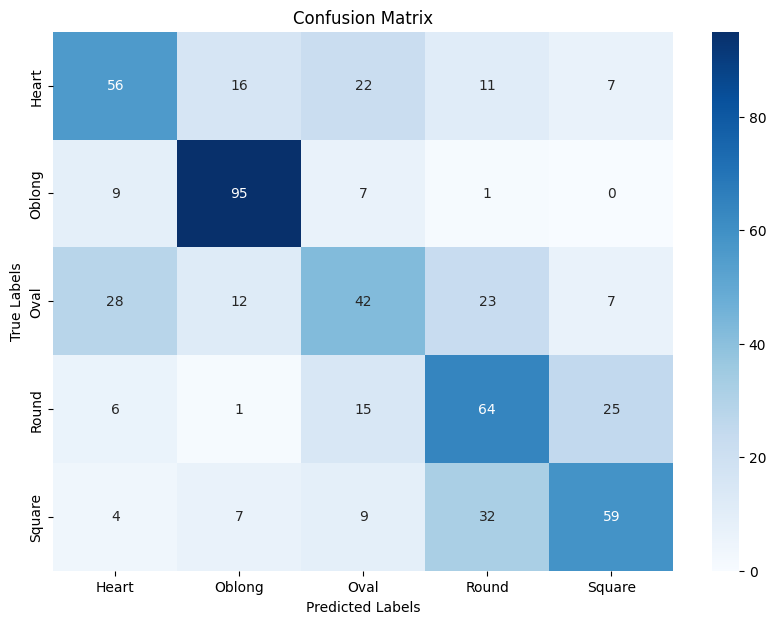

Classification Report:
               precision    recall  f1-score   support

       Heart       0.54      0.50      0.52       112
      Oblong       0.73      0.85      0.78       112
        Oval       0.44      0.38      0.41       112
       Round       0.49      0.58      0.53       111
      Square       0.60      0.53      0.56       111

    accuracy                           0.57       558
   macro avg       0.56      0.57      0.56       558
weighted avg       0.56      0.57      0.56       558



In [40]:
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Membuat confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:\n", cm)
# Visualisasi confusion matrix
plt.figure(figsize=(10, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=best_svc.classes_, yticklabels=best_svc.classes_)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()

# Laporan klasifikasi
print("Classification Report:\n", classification_report(y_test, y_pred))

In [41]:
import joblib

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit dan transform data training

# Simpan scaler ke file
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

In [42]:
# Simpan model ke file
joblib.dump(best_svc, 'best_svc_model.pkl')

print("Model berhasil disimpan!")


Model berhasil disimpan!
